## Practice: Fun with Word Embeddings (4 points total)

Today we gonna play with word embeddings: train our own little embeddings, load one from the gensim model zoo and use it to visualize text corpora.

This whole thing is gonna happen on top of an embedding dataset.

__Requirements:__  `pip install --upgrade nltk gensim bokeh`, but only if you're running locally.

**Please submit this notebook as part of your homework!**

In [ ]:
# download the data:
!wget https://www.dropbox.com/s/obaitrix9jyu84r/quora.txt?dl=1 -O ./quora.txt
# alternative download link: https://yadi.sk/i/BPQrUu1NaTduEw

--2025-11-21 05:46:00--  https://www.dropbox.com/s/obaitrix9jyu84r/quora.txt?dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.3.18, 2620:100:6018:18::a27d:312
Connecting to www.dropbox.com (www.dropbox.com)|162.125.3.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/p0t2dw6oqs6oxpd6zz534/quora.txt?rlkey=bjupppwua4zmd4elz8octecy9&dl=1 [following]
--2025-11-21 05:46:00--  https://www.dropbox.com/scl/fi/p0t2dw6oqs6oxpd6zz534/quora.txt?rlkey=bjupppwua4zmd4elz8octecy9&dl=1
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc8a4d6a467ce4e3666daa0d00be.dl.dropboxusercontent.com/cd/0/inline/C1limjELVRPCrUybl0lh3cqNgf4gbUdS4wDrvpzOaDtHwZ4_aFKEiH183D4gM1WyvRdme0Ek5xPZvnMfLsy5_XvF-1qL53EUT-7BGYmmf4WU7V7-MfPaK9f8UYwkrWkFfdM/file?dl=1# [following]
--2025-11-21 05:46:01--  https://uc8a4d6a467ce4e3666daa0d00be.dl.dropboxusercontent.com/cd/0/inline/C1limjELVRP

In [ ]:
import numpy as np

with open("./quora.txt", encoding="utf-8") as file:
    data = list(file)

data[50]

"What TV shows or books help you read people's body language?\n"

__Tokenization:__ a typical first step for an NLP task is to split raw data into words.
The text we're working with is in raw format: with all the punctuation and emojis attached to some words, so a simple str.split won't do.

Let's use __`nltk`__ - a library that handles many NLP tasks like tokenization, stemming, or part-of-speech tagging.

In [ ]:
from nltk.tokenize import WordPunctTokenizer
tokenizer = WordPunctTokenizer()

print(tokenizer.tokenize(data[50]))

['What', 'TV', 'shows', 'or', 'books', 'help', 'you', 'read', 'people', "'", 's', 'body', 'language', '?']


In [ ]:
# TASK: lowercase everything and extract tokens with tokenizer.
# data_tok should be a list of lists of tokens for each line in data.

data_tok = [tokenizer.tokenize(line.lower()) for line in data]  # YOUR CODE
data_tok[50]

['what',
 'tv',
 'shows',
 'or',
 'books',
 'help',
 'you',
 'read',
 'people',
 "'",
 's',
 'body',
 'language',
 '?']

In [ ]:
assert all(isinstance(row, (list, tuple)) for row in data_tok), "please convert each line into a list of tokens (strings)"
assert all(all(isinstance(tok, str) for tok in row) for row in data_tok), "please convert each line into a list of tokens (strings)"
is_latin = lambda tok: all('a' <= x.lower() <= 'z' for x in tok)
assert all(map(lambda l: not is_latin(l) or l.islower(), map(' '.join, data_tok))), "please make sure to lowercase the data"

In [ ]:
print([' '.join(row) for row in data_tok[:2]])

["can i get back with my ex even though she is pregnant with another guy ' s baby ?", 'what are some ways to overcome a fast food addiction ?']


__Word vectors:__ as the saying goes, there's more than one way to train word embeddings. There's Word2Vec and GloVe with different objective functions. Then there's fastText that uses character-level models to train word embeddings.

The choice is huge, so let's start someplace small: __gensim__ is another NLP library that features many vector-based models including word2vec.

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 68.3 MB/s eta 0:00:00


In [ ]:
from gensim.models import Word2Vec
model = Word2Vec(data_tok,
                 vector_size=32,      # embedding vector size
                 min_count=5,         # consider words that occurred at least 5 times
                 window=5).wv         # define context as a 5-word window around the target word

# From gensim docs
# wv: This object essentially contains the mapping between words and embeddings.
# After training, it can be used directly to query those embeddings in various ways.

In [ ]:
# now you can get word vectors !
model.get_vector('something')

array([-3.1928241 , -1.6241227 ,  0.42136356,  1.7251683 ,  0.45306027,
        1.9073576 ,  0.12656938, -4.1203504 ,  2.0913537 ,  2.3244774 ,
       -0.02618894,  4.4816647 ,  2.9379048 ,  2.2516856 ,  2.0587988 ,
       -0.7960612 ,  0.23301803, -2.0142508 ,  0.38989756, -2.349299  ,
       -3.5003428 ,  0.05647286, -3.4899766 , -3.298382  , -0.27590504,
       -3.4717433 , -1.0178709 , -1.2481867 , -0.37544134, -1.2952808 ,
       -1.419078  ,  0.38453504], dtype=float32)

In [ ]:
# or query similar words directly. Go play with it!
model.most_similar('man')

[('woman', 0.9375640749931335),
 ('person', 0.8607344031333923),
 ('boy', 0.845943033695221),
 ('guy', 0.832722008228302),
 ('lady', 0.820024311542511),
 ('girl', 0.8169060349464417),
 ('baby', 0.7959085702896118),
 ('kid', 0.7711374163627625),
 ('child', 0.7550601363182068),
 ('parent', 0.7515814900398254)]

### Using pre-trained model

Took it a while, huh? Now imagine training life-sized (100~300D) word embeddings on gigabytes of text: Wikipedia articles or Twitter posts.

Thankfully, nowadays you can get a pre-trained word embedding model in 2 lines of code (no SMS required, promise).

After being downloaded for the first time (or if you manually delete it), the model is saved in the `~/gensim_data` or `%USER_PATH%/gensim_data` directory. This can be checked by setting the return_path parameter to True.

In [ ]:
import gensim.downloader as api
model = api.load('glove-twitter-100')

[==================================================] 100.0% 387.1/387.1MB downloaded


In [ ]:
model.most_similar(positive=["coder", "money"], negative=["brain"])

[('broker', 0.5820155739784241),
 ('bonuses', 0.5424473881721497),
 ('banker', 0.5385112762451172),
 ('designer', 0.5197198390960693),
 ('merchandising', 0.4964233338832855),
 ('treet', 0.4922019839286804),
 ('shopper', 0.4920562207698822),
 ('part-time', 0.4912828207015991),
 ('freelance', 0.4843311905860901),
 ('aupair', 0.4796452820301056)]

```

```

```

```

```

```

```

```


# Visualizing data with word embeddings (1 point)

One way to see if our vectors are any good is to plot them. Thing is, those vectors are in 30D+ space and we humans are more used to 2-3D.

Luckily, we machine learners know about __dimensionality reduction__ methods.

Let's use that to plot 1000 most frequent words

In [ ]:
model.get_vector("cat")

array([ 0.38446  , -0.45507  ,  0.45351  ,  0.4301   , -0.050908 ,
       -0.26414  ,  0.43253  , -0.3166   ,  0.32214  ,  0.0064333,
       -0.47066  ,  0.95335  , -3.2063   ,  0.010913 , -0.27565  ,
        1.1732   ,  0.52033  , -0.045973 ,  0.094254 , -0.53846  ,
        0.0035668,  0.11934  , -0.17815  , -0.58093  ,  0.65081  ,
       -0.48746  , -0.50961  ,  0.42771  , -0.30638  ,  0.32385  ,
        0.33687  , -0.1717   , -0.39104  , -0.19038  ,  0.37016  ,
       -0.50396  ,  0.041969 , -0.20517  ,  0.3223   ,  0.41217  ,
       -0.42191  , -0.26359  , -0.1773   , -0.35658  ,  0.52145  ,
        0.57282  ,  0.60204  ,  0.74369  ,  0.33377  , -0.45041  ,
        0.015978 , -0.12575  ,  0.29786  , -0.77635  ,  0.23759  ,
        0.63821  ,  0.63726  ,  1.0079   ,  0.13714  , -0.031928 ,
       -0.21299  ,  0.52348  ,  0.67934  , -0.1427   , -0.64236  ,
       -0.47996  , -0.87915  ,  0.17501  ,  0.64517  ,  0.3778   ,
        0.53493  , -0.29723  , -0.25206  , -0.757    ,  0.3364

In [ ]:
# dir(model)

In [ ]:
words = model.index_to_key[:1000]

print(words[::100])

['<user>', '_', 'please', 'apa', 'justin', 'text', 'hari', 'playing', 'once', 'sei']


In [ ]:
# for each word, compute its vector with model
word_vectors = np.array([model.get_vector(w) for w in words])  # YOUR CODE

In [ ]:
assert isinstance(word_vectors, np.ndarray)
assert word_vectors.shape == (len(words), 100)
assert np.isfinite(word_vectors).all()

#### Linear projection: PCA

The simplest linear dimensionality reduction method is **P**rincipal **C**omponent **A**nalysis.

In geometric terms, PCA tries to find axes along which most of the variance occurs. The "natural" axes, if you wish.

<img src="https://github.com/yandexdataschool/Practical_RL/raw/master/yet_another_week/_resource/pca_fish.png" style="width:30%">


Under the hood, it attempts to decompose object-feature matrix $X$ into two smaller matrices: $W$ and $\hat W$ minimizing _mean squared error_:

$$\|(X W) \hat{W} - X\|^2_2 \to_{W, \hat{W}} \min$$
- $X \in \mathbb{R}^{n \times m}$ - object matrix (**centered**);
- $W \in \mathbb{R}^{m \times d}$ - matrix of direct transformation;
- $\hat{W} \in \mathbb{R}^{d \times m}$ - matrix of reverse transformation;
- $n$ samples, $m$ original dimensions and $d$ target dimensions;



In [ ]:
from sklearn.decomposition import PCA

# map word vectors onto 2d plane with PCA. Use good old sklearn API (fit, transform)
# after that, normalize vectors to make sure they have zero mean and unit variance
word_vectors_pca = []  # YOUR CODE

# and maybe MORE OF YOUR CODE here :)

In [ ]:
word_vectors.shape

(1000, 100)

In [ ]:
dir(PCA)

pca = PCA(n_components=2, whiten=True)
pca.fit(word_vectors)

PCA(n_components=2, whiten=True)

In [ ]:
word_vectors_pca = pca.transform(word_vectors)

In [ ]:
assert word_vectors_pca.shape == (len(word_vectors), 2), "there must be a 2d vector for each word"
assert max(abs(word_vectors_pca.mean(0))) < 1e-5, "points must be zero-centered"
assert max(abs(1.0 - word_vectors_pca.std(0))) < 1e-2, "points must have unit variance"

#### Let's draw it!

In [ ]:
import bokeh.models as bm, bokeh.plotting as pl
from bokeh.io import output_notebook
output_notebook()

def draw_vectors(x, y, radius=10, alpha=0.25, color='blue',
                 width=600, height=400, show=True, **kwargs):
    """ draws an interactive plot for data points with auxilirary info on hover """
    if isinstance(color, str): color = [color] * len(x)
    data_source = bm.ColumnDataSource({ 'x' : x, 'y' : y, 'color': color, **kwargs })

    fig = pl.figure(active_scroll='wheel_zoom', width=width, height=height)
    fig.scatter('x', 'y', size=radius, color='color', alpha=alpha, source=data_source)

    fig.add_tools(bm.HoverTool(tooltips=[(key, "@" + key) for key in kwargs.keys()]))
    if show: pl.show(fig)
    return fig

In [ ]:
draw_vectors(word_vectors_pca[:, 0], word_vectors_pca[:, 1], token=words)

# hover a mouse over there and see if you can identify the clusters

figure(id='p1006', ...)

#### Visualizing neighbors with t-SNE
PCA is nice but it's strictly linear and thus only able to capture coarse high-level structure of the data.

If we instead want to focus on keeping neighboring points near, we could use TSNE, which is itself an embedding method. Here you can read __[more on TSNE](https://distill.pub/2016/misread-tsne/)__.

In [ ]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize

# map word vectors onto 2d plane with TSNE. hint: don't panic, it may take a minute or two to fit.
# normalize them as just like with PCA
tsne = TSNE(n_components=2)

word_tsne = normalize(tsne.fit_transform(word_vectors))  # YOUR CODE

In [ ]:
word_tsne[0]

array([0.6717762, 0.7407542], dtype=float32)

In [ ]:
draw_vectors(word_tsne[:, 0], word_tsne[:, 1], color='green', token=words)

figure(id='p1057', ...)

### Visualizing phrases

Word embeddings can also be used to represent short phrases. The simplest way is to take __an average__ of vectors for all tokens in the phrase with some weights.

This trick is useful to identify what data are you working with: find if there are any outliers, clusters or other artifacts.

Let's try this new hammer on our data!


In [ ]:
def get_phrase_embedding(phrase):
    """
    Convert phrase to a vector by aggregating it's word embeddings. See description above.
    """
    # 1. lowercase phrase
    # 2. tokenize phrase
    # 3. average word vectors for all words in tokenized phrase
    # skip words that are not in model's vocabulary
    # if all words are missing from vocabulary, return zeros

    zero_vector = np.zeros([model.vector_size], dtype='float32')
    vectors = []
    for tok in tokenizer.tokenize(phrase.lower()):
        if tok in model:
            vectors.append(model[tok])
    if not vectors:
        return zero_vector
    return np.mean(vectors, axis=0)



In [ ]:
v = get_phrase_embedding("I'm very sure. This never happened to me before...")
v.shape

(100,)

In [ ]:
vector = get_phrase_embedding("I'm very sure. This never happened to me before...")

assert np.allclose(vector[::10],
                   np.array([ 0.31807372, -0.02558171,  0.0933293 , -0.1002182 , -1.0278689 ,
                             -0.16621883,  0.05083408,  0.17989802,  1.3701859 ,  0.08655966],
                              dtype=np.float32))
assert np.array_equal(get_phrase_embedding("thisisgibberish"), np.zeros([model.vector_size], dtype='float32')), "corner case for all missing words should be handled as described in the function comments"

In [ ]:
# let's only consider ~5k phrases for a first run.
chosen_phrases = data[::len(data) // 1000]

# compute vectors for chosen phrases
phrase_vectors = np.array([get_phrase_embedding(text) for text in chosen_phrases])  # YOUR CODE

In [ ]:
phrase_vectors.shape

(1001, 100)

In [ ]:
assert isinstance(phrase_vectors, np.ndarray) and np.isfinite(phrase_vectors).all()
assert phrase_vectors.shape == (len(chosen_phrases), model.vector_size)

In [ ]:
# map vectors into 2d space with pca, tsne or your other method of choice
# don't forget to normalize

phrase_vectors_2d = TSNE().fit_transform(phrase_vectors)

phrase_vectors_2d = (phrase_vectors_2d - phrase_vectors_2d.mean(axis=0)) / phrase_vectors_2d.std(axis=0)

In [ ]:
draw_vectors(phrase_vectors_2d[:, 0], phrase_vectors_2d[:, 1],
             phrase=[phrase[:50] for phrase in chosen_phrases],
             radius=20,)

figure(id='p1108', ...)

**There's more below! Scroll down when you're ready.**

### Text Classification: Prohibited Comment Classification

![img](https://github.com/yandexdataschool/nlp_course/raw/master/resources/banhammer.jpg)

__In this notebook__ you will build an algorithm that classifies social media comments into normal or toxic.
Like in many real-world cases, you only have a small (10^3) dataset of hand-labeled examples to work with. We'll tackle this problem using both classical nlp methods and embedding-based approach.

In [ ]:
# if you're in colab, download the data:
!wget https://raw.githubusercontent.com/yandexdataschool/nlp_course/refs/heads/2025/week01_embeddings/comments.tsv -O ./comments.tsv -q

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
data = pd.read_csv("comments.tsv", sep='\t')

texts = data['comment_text'].values
target = data['should_ban'].values
data[50::200]

,should_ban,comment_text
50,0,"""Those who're in advantageous positions are th..."
250,1,Fartsalot56 says f**k you motherclucker!!
450,1,"Are you a fool? \n\nI am sorry, but you seem t..."
650,1,I AM NOT A VANDAL!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
850,0,Citing sources\n\nCheck out the Wikipedia:Citi...


In [ ]:
from sklearn.model_selection import train_test_split
texts_train, texts_test, y_train, y_test = train_test_split(texts, target, test_size=0.5, random_state=42)

__Note:__ it is generally a good idea to split data into train/test before anything is done to them.

It guards you against possible data leakage in the preprocessing stage. For example, should you decide to select words present in obscene tweets as features, you should only count those words over the training set. Otherwise your algoritm can cheat evaluation.

### Preprocessing and tokenization

Comments contain raw text with punctuation, upper/lowercase letters and even newline symbols.

To simplify all further steps, we'll split text into space-separated tokens using one of nltk tokenizers.

In [ ]:
from nltk.tokenize import TweetTokenizer
tokenizer = TweetTokenizer()
preprocess = lambda text: ' '.join(tokenizer.tokenize(text.lower()))

text = 'How to be a grown-up at work: replace "fuck you" with "Ok, great!".'
print("before:", text,)
print("after:", preprocess(text),)

before: How to be a grown-up at work: replace "fuck you" with "Ok, great!".
after: how to be a grown-up at work : replace " fuck you " with " ok , great ! " .


In [ ]:
# task: preprocess each comment in train and test

texts_train = [preprocess(text) for text in texts_train]  # YOUR CODE
texts_test = [preprocess(text) for text in texts_test]  # YOUR CODE

In [ ]:
assert texts_train[5] ==  'who cares anymore . they attack with impunity .'
assert texts_test[89] == 'hey todds ! quick q ? why are you so gay'
assert len(texts_test) == len(y_test)

### Solving it: bag of words (1 point)

![img](http://www.novuslight.com/uploads/n/BagofWords.jpg)

One traditional approach to such problem is to use bag of words features:
1. build a vocabulary of frequent words (use train data only)
2. for each training sample, count the number of times a word occurs in it (for each word in vocabulary).
3. consider this count a feature for some classifier

__Note:__ in practice, you can compute such features using sklearn. Please don't do that in the current assignment, though.
* `from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer`

In [ ]:
# task: find up to k most frequent tokens in texts_train,
# sort them by number of occurrences (highest first)
from collections import Counter
word_counter = Counter()
k = 10000
for text in texts_train:
    word_counter.update(text.split())

bow_vocabulary = [tok for tok, _ in word_counter.most_common(k)] # YOUR CODE

print('example features:', sorted(bow_vocabulary)[::100])

example features: ['!', '12:20', '300', '_', 'adorned', 'alternative', 'archive', 'average', 'benkner', 'bout', 'came', 'chest', 'combined', 'consumers', 'cricket', 'decisions', 'dickheads', 'domestic', 'eductaion', 'essentially', 'faggot', 'firms', 'frustrated', 'goal', 'hanibal', 'hip-hop', 'identified', 'infoboxes', 'issue', 'kindergarten', 'lets', 'lot', "mclaren's", 'moderator', 'naturally', 'noticeable', 'opposing', 'pdf', 'plant', 'pretoria', 'punctuation', 'rebels', 'repetative', 'riadh', 'schulz', 'shes', 'slit', 'spoof', 'stupid', 't', 'theoretical', 'topic', 'uglyness', 'userspace', 'wanted', 'wikieditor', 'year', '←']


In [ ]:
def text_to_bow(text):
    """ convert text string to an array of token counts. Use bow_vocabulary. """
    vector = []
    for tok in bow_vocabulary:
        vector.append(text.split().count(tok))

    return np.array(vector, 'float32')

In [ ]:
X_train_bow = np.stack(list(map(text_to_bow, texts_train)))
X_test_bow = np.stack(list(map(text_to_bow, texts_test)))

In [ ]:
k_max = len(set(' '.join(texts_train).split()))
assert X_train_bow.shape == (len(texts_train), min(k, k_max))
assert X_test_bow.shape == (len(texts_test), min(k, k_max))
assert np.all(X_train_bow[5:10].sum(-1) == np.array([len(s.split()) for s in  texts_train[5:10]]))
assert len(bow_vocabulary) <= min(k, k_max)
assert X_train_bow[6, bow_vocabulary.index('.')] == texts_train[6].split().count('.')

In [ ]:
X_train_bow.shape, y_train.shape

((500, 5707), (500,))

We shall use a simple linear model: __Logistic Regression__.
It might not be the fanciest one around, but the simplicity has its own advantages: a linear model is blazingly fast and needs less data to fit.
Let's sklearn it!

In [57]:
import numpy as np
from sklearn.linear_model import LogisticRegression
bow_model = LogisticRegression(random_state=42)  # YOUR CODE HERE - train a logistic regression
bow_model.fit(X_train_bow, y_train)

LogisticRegression(random_state=42)

In [58]:
# Tune C

from sklearn.model_selection import GridSearchCV
param_grid = {
    'C': np.logspace(start=-3, stop=3, num=10),
}

# Initialize GridSearchCV
grid_search = GridSearchCV(bow_model, param_grid, cv=5, scoring='roc_auc')

# Fit the data
grid_search.fit(X_train_bow, y_train)

# Access the best results
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best score: {grid_search.best_score_}")
print(f"Best estimator: {grid_search.best_estimator_}")

Best parameters: {'C': np.float64(215.44346900318823)}
Best score: 0.8525181036346231
Best estimator: LogisticRegression(C=np.float64(215.44346900318823), random_state=42)


In [59]:
bow_model = LogisticRegression(random_state=42, C=grid_search.best_params_["C"])  # YOUR CODE HERE - train a logistic regression
bow_model.fit(X_train_bow, y_train)

LogisticRegression(C=np.float64(215.44346900318823), random_state=42)

Model accuracy: 0.772
Well done!


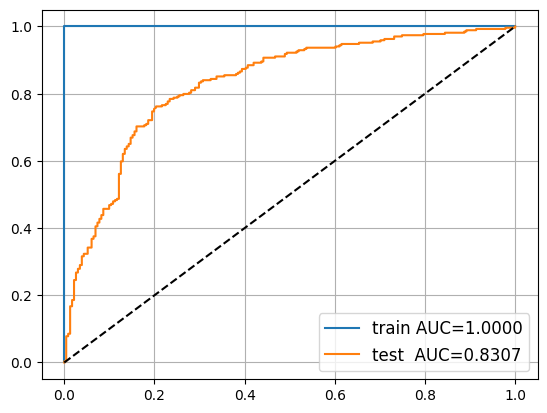

In [60]:
from sklearn.metrics import roc_auc_score, roc_curve

for name, X, y, model in [
    ('train', X_train_bow, y_train, bow_model),
    ('test ', X_test_bow, y_test, bow_model)
]:
    proba = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, proba)
    plt.plot(*roc_curve(y, proba)[:2], label='%s AUC=%.4f' % (name, auc))

plt.plot([0, 1], [0, 1], '--', color='black',)
plt.legend(fontsize='large')
plt.grid()

test_accuracy = np.mean(bow_model.predict(X_test_bow) == y_test)
print(f"Model accuracy: {test_accuracy:.3f}")
assert test_accuracy > 0.77, "Hint: tune the parameter C to improve performance"
print("Well done!")

### Task: implement TF-IDF features (1 point)

Not all words are equally useful. One can prioritize rare words and downscale words like "and"/"or" by using __tf-idf features__. This abbreviation stands for __text frequency/inverse document frequency__ and means exactly that:

$$ \text{feature}_i = \frac{\text{Count}(word_i \in x)}{\text{Total number of words in } x} \times \log\left(\frac{N}{\text{Count}(word_i \in D) + \alpha}\right) $$


, where x is a single text, D is your dataset (a collection of texts), N is a total number of documents and $\alpha$ is a smoothing hyperparameter (typically 1).
And $Count(word_i \in D)$ is the number of documents where $word_i$ appears.

It may also be a good idea to normalize each data sample after computing tf-idf features.

__Your task:__ implement tf-idf features, train a model and evaluate ROC curve. Compare it with basic BagOfWords model from above.

Please don't use sklearn/nltk built-in tf-idf vectorizers in your solution :) You can still use 'em for debugging though.

We have tokenized texts. For each unique token in the trainset we calculate:
 - Count(word, x)
 - Count(word, D)

 For each text we calc total number of words

 Create dict where tokens will be keys and tf-idf values will be values

In [ ]:
len(texts_train), len(texts_test)

(500, 500)

In [ ]:
type(texts_train)

list

In [ ]:
X_train = pd.DataFrame({"text": texts_train})
X_test = pd.DataFrame({"text": texts_test})

In [ ]:
# def calc_word_in_text(row, word):
#     return row["text"].split().count(word) / len(row["text"])

# for word in bow_vocabulary:
#     X_train[f"count_{word}"] = X_train.apply(lambda row: calc_word_in_text(row, word), axis=1)

# X_train.head(2)

In [ ]:
from collections import defaultdict
import numpy as np

# 1. Initialize DF dictionary and alpha
df = defaultdict(int)
alpha = 1

# 2-4. Iterate through texts to calculate DF
for text in texts_train:
    unique_words_in_doc = set(text.split())
    for word in unique_words_in_doc:
        if word in bow_vocabulary:
            df[word] += 1

# 5. Calculate IDF
idf = {}
N = len(texts_train)
for word in bow_vocabulary:
    idf[word] = np.log(N / (df[word] + alpha))

print("Calculated DF and IDF for words in bow_vocabulary.")
# Display a few example IDF values
print("Example IDF values:")
for i, word in enumerate(bow_vocabulary[:5]):
    print(f"  {word}: {idf[word]:.4f}")

Calculated DF and IDF for words in bow_vocabulary.
Example IDF values:
  .: 0.2614
  ,: 0.5413
  you: 0.6852
  the: 0.5482
  ": 1.3704


**Reasoning**:
The next step is to implement the `text_to_tfidf` function as described in the main task, which will convert text strings into TF-IDF vectors using the calculated IDF values and `bow_vocabulary`. This function will then be applied to both `texts_train` and `texts_test` to generate `X_train_tfidf` and `X_test_tfidf`.



In [ ]:
def text_to_tfidf(text):
    """ Convert text string to an array of TF-IDF features. """
    vector = np.zeros(len(bow_vocabulary), dtype='float32')
    text_tokens = text.split()
    total_words_in_text = len(text_tokens)

    if total_words_in_text == 0:
        return vector

    word_counts = defaultdict(int)
    for token in text_tokens:
        word_counts[token] += 1

    for i, word in enumerate(bow_vocabulary):
        tf = word_counts[word] / total_words_in_text
        # Use idf calculated earlier, default to alpha for words not in idf
        # The idf dictionary already contains only words in bow_vocabulary, so this check is mostly for safety.
        inverse_document_frequency = idf.get(word, np.log(N / (alpha)))
        vector[i] = tf * inverse_document_frequency

    return vector

X_train_tfidf = np.stack(list(map(text_to_tfidf, texts_train)))
X_test_tfidf = np.stack(list(map(text_to_tfidf, texts_test)))

print("Generated TF-IDF features for training and test sets.")
print(f"X_train_tfidf shape: {X_train_tfidf.shape}")
print(f"X_test_tfidf shape: {X_test_tfidf.shape}")


Generated TF-IDF features for training and test sets.
X_train_tfidf shape: (500, 5707)
X_test_tfidf shape: (500, 5707)


**Reasoning**:
The next step is to normalize the TF-IDF feature matrices using L2 normalization, as suggested in the problem description, to ensure that all vectors have a unit norm. This helps improve the performance of many machine learning algorithms.



In [ ]:
from sklearn.preprocessing import normalize

X_train_tfidf_normalized = normalize(X_train_tfidf, axis=1)
X_test_tfidf_normalized = normalize(X_test_tfidf, axis=1)

print("Normalized TF-IDF features for training and test sets.")
print(f"X_train_tfidf_normalized shape: {X_train_tfidf_normalized.shape}")
print(f"X_test_tfidf_normalized shape: {X_test_tfidf_normalized.shape}")

Normalized TF-IDF features for training and test sets.
X_train_tfidf_normalized shape: (500, 5707)
X_test_tfidf_normalized shape: (500, 5707)


**Reasoning**:
Now that the TF-IDF features are normalized, I will train a Logistic Regression model on the normalized training data (`X_train_tfidf_normalized`) and tune its 'C' hyperparameter using GridSearchCV to find the optimal regularization strength.



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

# Initialize Logistic Regression model
tfidf_model = LogisticRegression(random_state=42, solver='liblinear') # Use 'liblinear' solver for better convergence on smaller datasets and L1/L2 regularization

# Define parameter grid for GridSearchCV
param_grid = {
    'C': np.logspace(-3, 3, 10)  # Example C values: 0.001, 0.01, 0.1, 1, 10, 100, 1000
}

# Initialize GridSearchCV
grid_search_tfidf = GridSearchCV(tfidf_model, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)

# Fit GridSearchCV to find the best C parameter
grid_search_tfidf.fit(X_train_tfidf_normalized, y_train)

# Get the best estimator
tfidf_model_best = grid_search_tfidf.best_estimator_

print(f"Best parameters for TF-IDF model: {grid_search_tfidf.best_params_}")
print(f"Best ROC AUC score on validation sets: {grid_search_tfidf.best_score_:.4f}")

# Train the final model with the best parameters on the full training data
tfidf_model_best.fit(X_train_tfidf_normalized, y_train)

print("TF-IDF Logistic Regression model trained with best C parameter.")

Best parameters for TF-IDF model: {'C': np.float64(100.0)}
Best ROC AUC score on validation sets: 0.8912
TF-IDF Logistic Regression model trained with best C parameter.


Model accuracy: 0.786
Well done!


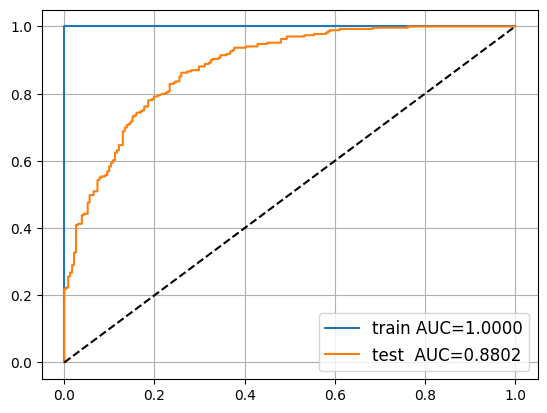

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve

for name, X, y, model in [
    ('train', X_train_tfidf_normalized, y_train, tfidf_model_best),
    ('test ', X_test_tfidf_normalized, y_test, tfidf_model_best)
]:
    proba = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, proba)
    plt.plot(*roc_curve(y, proba)[:2], label='%s AUC=%.4f' % (name, auc))

plt.plot([0, 1], [0, 1], '--', color='black',)
plt.legend(fontsize='large')
plt.grid()

test_accuracy = np.mean(tfidf_model_best.predict(X_test_tfidf_normalized) == y_test)
print(f"Model accuracy: {test_accuracy:.3f}")
assert test_accuracy > 0.77, "Hint: tune the parameter C to improve performance"
print("Well done!")

Scroll down when you're done with TF-IDF!
```

```

```

```

```

```

```

```

```

```

```

```

```

```

```

```


### Solving it better: word vectors (1 point)

Let's try another approach: instead of counting per-word frequencies, we shall map all words to pre-trained word vectors and average over them to get text features.

This should give us two key advantages: (1) we now have 10^2 features instead of 10^4 and (2) our model can generalize to word that are not in training dataset.

We begin with a standard approach with pre-trained word vectors. However, you may also try
* training embeddings from scratch on relevant (unlabeled) data
* multiplying word vectors by inverse word frequency in dataset (like tf-idf).
* concatenating several embeddings
    * call `gensim.downloader.info()['models'].keys()` to get a list of available models
* clusterizing words by their word-vectors and try bag of cluster_ids

__Note:__ loading pre-trained model may take a while. It's a perfect opportunity to refill your cup of tea/coffee and grab some extra cookies. Or binge-watch some tv series if you're slow on internet connection

In [ ]:
!pip install --upgrade gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 58.8 MB/s eta 0:00:00


In [ ]:
import gensim.downloader
gensim.downloader.info()['models'].keys()

dict_keys(['fasttext-wiki-news-subwords-300', 'conceptnet-numberbatch-17-06-300', 'word2vec-ruscorpora-300', 'word2vec-google-news-300', 'glove-wiki-gigaword-50', 'glove-wiki-gigaword-100', 'glove-wiki-gigaword-200', 'glove-wiki-gigaword-300', 'glove-twitter-25', 'glove-twitter-50', 'glove-twitter-100', 'glove-twitter-200', '__testing_word2vec-matrix-synopsis'])

In [20]:
import gensim.downloader
embeddings = gensim.downloader.load("fasttext-wiki-news-subwords-300")

# If you're low on RAM or download speed, use "glove-wiki-gigaword-100" instead. Ignore all further asserts.

[==================================================] 100.0% 958.5/958.4MB downloaded


In [48]:
def vectorize_sum(comment):
    """
    implement a function that converts preprocessed comment to a sum of token vectors
    """
    embedding_dim = embeddings.vectors.shape[1]
    features = np.zeros([embedding_dim], dtype='float32')

    features = np.sum([embeddings.get_vector(word) for word in comment.split()
            if word in embeddings.key_to_index], axis=0)
    return features

assert np.allclose(
    vectorize_sum("who cares anymore . they attack with impunity .")[::70],
    np.array([ 0.0108616 ,  0.0261663 ,  0.13855131, -0.18510573, -0.46380025])
)

In [50]:
X_train_wv = np.stack([vectorize_sum(text) for text in texts_train])
X_test_wv = np.stack([vectorize_sum(text) for text in texts_test])

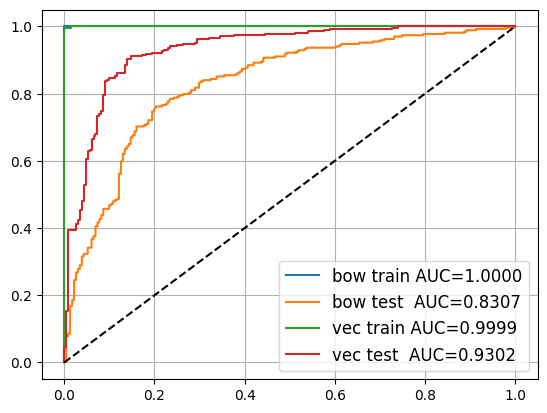

In [62]:
from sklearn.linear_model import LogisticRegression

wv_model = LogisticRegression(solver="liblinear").fit(X_train_wv, y_train)

for name, X, y, model in [
    ('bow train', X_train_bow, y_train, bow_model),
    ('bow test ', X_test_bow, y_test, bow_model),
    ('vec train', X_train_wv, y_train, wv_model),
    ('vec test ', X_test_wv, y_test, wv_model)
]:
    proba = model.predict_proba(X)[:, 1]
    auc = roc_auc_score(y, proba)
    plt.plot(*roc_curve(y, proba)[:2], label='%s AUC=%.4f' % (name, auc))

plt.plot([0, 1], [0, 1], '--', color='black',)
plt.legend(fontsize='large')
plt.grid()

assert roc_auc_score(y_test, wv_model.predict_proba(X_test_wv)[:, 1]) > 0.92, "something's wrong with your features"

If everything went right, you've just managed to reduce misclassification rate by a factor of two.
This trick is very useful when you're dealing with small datasets. However, if you have hundreds of thousands of samples, there's a whole different range of methods for that. We'll get there in the second part.

**Would you like to know more?**
* See what other embeddings are there in the model zoo: `gensim.downloader.info()`
* Take a look at [FastText embeddings](https://github.com/facebookresearch/fastText)

## Объяснение хеширования n-грамм

### Subtask:
Рассказать о том, как FastText использует хеш-функции для сопоставления n-грамм с фиксированным размером таблицы эмбеддингов, чтобы эффективно обрабатывать большое количество n-грамм.


## Объяснение хеширования n-грамм

### Subtask:
Рассказать о том, как FastText использует хеш-функции для сопоставления n-грамм с фиксированным размером таблицы эмбеддингов, чтобы эффективно обрабатывать большое количество n-грамм.

#### Инструкции
1. Объясните, что такое n-граммы в контексте FastText и зачем они используются (например, для обработки Out-Of-Vocabulary слов и морфологии).
2. Опишите, как FastText преобразует каждое слово в набор его символьных n-грамм (например, для слова 'apple' и n=3, это будут '<ap', 'app', 'ppl', 'ple', 'le>' и 'apple' как целое слово).
3. Расскажите о роли хеш-функций в FastText: как они используются для отображения большого количества потенциальных n-грамм на фиксированный (меньший) размер таблицы векторов эмбеддингов.
4. Объясните механизм хеширования, включая 'collisions' (коллизии) и то, как FastText обрабатывает их (например, несколько n-грамм могут быть отображены на один и тот же индекс в таблице).
5. Обсудите преимущества такого подхода: эффективное использование памяти (фиксированный размер таблицы) и способность обрабатывать практически бесконечное количество n-грамм, что критично для языков с богатой морфологией.

### Объяснение хеширования n-грамм в FastText

#### 1. Что такое n-граммы и зачем они нужны в FastText?
В контексте FastText, **n-граммы** - это последовательности из `n` символов внутри слова. Например, для слова "apple" и n=3, его символьные 3-граммы будут "app", "ppl", "ple". FastText также добавляет специальные символы `<` и `>` в начало и конец слова, чтобы отличать префиксы и суффиксы от других n-грамм. Так, для слова "apple" (n=3) будут сгенерированы следующие n-граммы: `<ap`, `app`, `ppl`, `ple`, `le>`. Само слово "apple" также рассматривается как отдельный токен.

**Зачем они используются?** Основные причины использования n-грамм в FastText:
*   **Обработка Out-Of-Vocabulary (OOV) слов:** Традиционные Word2Vec модели не могут генерировать эмбеддинги для слов, которые не были встречены во время обучения. FastText решает эту проблему, представляя слова как сумму эмбеддингов их n-грамм. Если новое слово встречается, его эмбеддинг может быть составлен из эмбеддингов его n-грамм, даже если само слово не было в словаре.
*   **Учет морфологии:** Многие языки (особенно флективные, как русский, немецкий или турецкий) имеют богатую морфологию, где значения слов сильно зависят от их частей (приставок, суффиксов, корней). N-граммы позволяют FastText улавливать эти морфологические особенности, поскольку общие части слов (например, корни) будут иметь общие n-граммы и, соответственно, вносить вклад в похожие эмбеддинги.
*   **Снижение размерности словаря:** Вместо того чтобы хранить эмбеддинги для каждого уникального слова, FastText хранит эмбеддинги для n-грамм, что позволяет более компактно представлять словари больших размеров.

#### 2. Преобразование слова в набор символьных n-грамм
Как было упомянуто выше, FastText преобразует каждое слово в набор его символьных n-грамм. Для слова `apple` с минимальной длиной n-граммы `min_n=3` и максимальной длиной `max_n=3`, процесс выглядит так:
1.  Слово дополняется `<` и `>`: `<apple>`
2.  Генерируются 3-граммы:
    *   `<ap`
    *   `app`
    *   `ppl`
    *   `ple`
    *   `le>`
3.  Само слово `apple` также добавляется в качестве отдельной единицы.

Если `min_n=3` и `max_n=5`, то будут сгенерированы также 4-граммы (`<app`, `appl`, `pple`, `ple>`) и 5-граммы (`<appl`, `apple`, `pple>`), а также само слово `apple`.

#### 3. Роль хеш-функций
Количество возможных n-грамм может быть огромным, особенно если учитывать различные длины n-грамм и большой алфавит. Хранить уникальный эмбеддинг для каждой возможной n-граммы было бы неэффективно и требовало бы огромных объемов памяти.

Здесь на помощь приходят **хеш-функции**. FastText использует хеш-функцию для сопоставления каждой n-граммы с индексом в таблице эмбеддингов **фиксированного размера**. Вместо того чтобы иметь словарь всех n-грамм, FastText создает фиксированный массив (`bucket` или `hash table`) размером, скажем, 2 миллиона или 10 миллионов ячеек. Каждая n-грамма, встречающаяся в тексте, хешируется, и полученное хеш-значение (модулированное по размеру массива) используется как индекс для получения ее эмбеддинга.

Таким образом, каждая n-грамма получает свой вектор из этого фиксированного массива. Эмбеддинг слова затем вычисляется как сумма (или среднее) векторов его n-грамм и вектора самого слова.

#### 4. Механизм хеширования и коллизии
Процесс хеширования в FastText обычно включает стандартные алгоритмы хеширования, которые преобразуют строку (n-грамму) в целое число. Затем это целое число используется как индекс в таблице эмбеддингов.

**Коллизии (Collisions):** Поскольку количество возможных n-грамм значительно больше, чем фиксированный размер хеш-таблицы, неизбежно возникновение **коллизий**. Коллизия происходит, когда две или более разные n-граммы хешируются в один и тот же индекс в таблице. Это означает, что эти разные n-граммы будут "делить" один и тот же вектор эмбеддинга.

**Как FastText обрабатывает коллизии:** FastText не пытается активно избегать коллизий или разрешать их в традиционном смысле (например, через цепочки или открытую адресацию). Вместо этого, он просто позволяет им происходить. Эмбеддинг, хранящийся по данному индексу, становится "усредненным" представлением всех n-грамм, которые хешируются в этот индекс. Хотя это может показаться недостатком, на практике это работает удивительно хорошо и даже может выступать в качестве формы регуляризации, способствуя обобщению модели.

#### 5. Преимущества такого подхода
*   **Эффективное использование памяти:** Фиксированный размер таблицы эмбеддингов означает, что объем памяти, необходимый для хранения n-грамм, не зависит от размера словаря n-грамм, а только от выбранного размера таблицы. Это позволяет обрабатывать очень большие объемы текста без перегрузки памяти.
*   **Обработка практически бесконечного количества n-грамм:** Поскольку любая n-грамма (даже та, которая никогда не встречалась в обучающих данных) может быть хеширована в один из фиксированных "бакетов", модель FastText способна эффективно работать с огромным разнообразием n-грамм. Это особенно полезно для языков с богатой морфологией, где новые слова или формы слов постоянно генерируются.
*   **Robustness к опечаткам и редким словам:** Небольшие изменения в слове (например, опечатки) могут привести к тому, что только несколько n-грамм изменятся, а большая часть останется прежней, позволяя модели сохранять некоторую степень понимания. Точно так же, редкие слова, которые не имеют собственных эмбеддингов, все еще могут быть представлены через их n-граммы.
*   **Ускорение обучения:** Поскольку нет необходимости создавать и поддерживать огромный словарь всех возможных n-грамм, процесс обучения ускоряется.

**Reasoning**:
I need to add a new markdown cell that provides a detailed explanation of FastText's n-gram hashing mechanism, covering its purpose, how n-grams are formed, the role of hash functions, collision handling, and the benefits of this approach. The provided content in the prompt is exactly what is needed for this explanation.

